In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, roc_curve, precision_recall_curve, average_precision_score
)

In [5]:
train_path = r"C:\Users\srira\Downloads\DDSM Dataset\Train"
valid_path = r"C:\Users\srira\Downloads\DDSM Dataset\Valid"
test_path  = r"C:\Users\srira\Downloads\DDSM Dataset\Test"

In [8]:
def load_dataset(path):
    images = []
    labels = []

    for class_name in ['Benign', 'Malignant']:
        folder = os.path.join(path, class_name)
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            for img_path in glob(os.path.join(folder, ext)):
                images.append(img_path)
                labels.append(class_name)

    return images, labels

train_imgs, train_labels = load_dataset(train_path)
valid_imgs, valid_labels = load_dataset(valid_path)
test_imgs, test_labels = load_dataset(test_path)

print("Train:", len(train_imgs))
print("Valid:", len(valid_imgs))
print("Test:", len(test_imgs))

Train: 2100
Valid: 450
Test: 450


In [9]:
from collections import Counter

print("Train Distribution:", Counter(train_labels))
print("Test Distribution:", Counter(test_labels))

Train Distribution: Counter({'Malignant': 1260, 'Benign': 840})
Test Distribution: Counter({'Malignant': 270, 'Benign': 180})


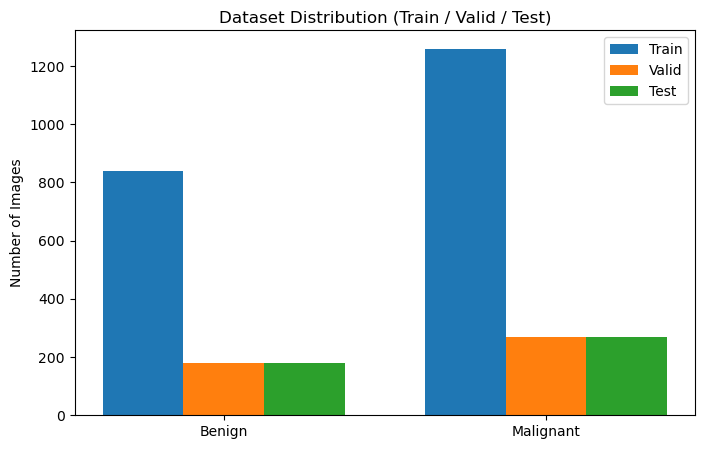

In [11]:
labels = ['Benign', 'Malignant']
train_count = Counter(train_labels)
valid_count = Counter(valid_labels)
test_count  = Counter(test_labels)

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(8,5))
plt.bar(
    x - w,
    [train_count['Benign'], train_count['Malignant']],
    w,
    label='Train'
)
plt.bar(
    x,
    [valid_count['Benign'], valid_count['Malignant']],
    w,
    label='Valid'
)
plt.bar(
    x + w,
    [test_count['Benign'], test_count['Malignant']],
    w,
    label='Test'
)

plt.xticks(x, labels)
plt.legend()
plt.title("Dataset Distribution (Train / Valid / Test)")
plt.ylabel("Number of Images")
plt.show()

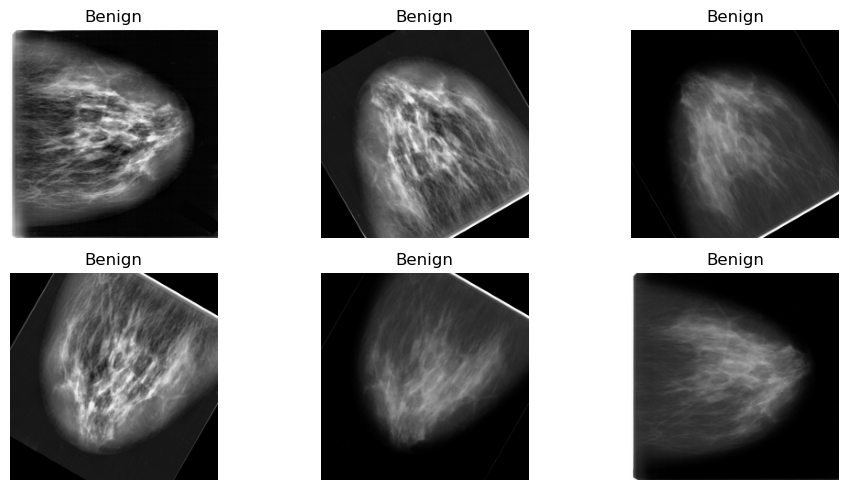

In [12]:
def show_samples(images, labels):
    plt.figure(figsize=(10,5))
    n = min(6, len(images))
    for i in range(n):
        img = cv2.imread(images[i], 0)
        plt.subplot(2, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(labels[i])   # labels are now 'Benign' / 'Malignant'
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_imgs, train_labels)


In [13]:
IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [14]:
def remove_background(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        x,y,w,h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]
    
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

In [15]:
def denoise(img):
    img = cv2.GaussianBlur(img, (5,5), 0)
    img = cv2.medianBlur(img, 5)
    return img

In [16]:
def enhance(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0)
    cl = clahe.apply(l)
    
    merged = cv2.merge((cl,a,b))
    img = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    
    return img / 255.0

In [17]:
def extract_roi(img):
    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        return img, area, perimeter
    
    return img, 0, 0

In [18]:
def build_unet(input_shape=(224,224,3)):
    inputs = tf.keras.layers.Input(input_shape)

    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(p2)

    u1 = tf.keras.layers.UpSampling2D()(c3)
    u1 = tf.keras.layers.concatenate([u1, c2])
    c4 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = tf.keras.layers.UpSampling2D()(c4)
    u2 = tf.keras.layers.concatenate([u2, c1])
    c5 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return tf.keras.Model(inputs, outputs)

In [19]:
unet = build_unet()
unet.compile(optimizer='adam', loss='binary_crossentropy')

# Example segmentation output
def get_mask(img):
    img = np.expand_dims(img, axis=0)
    mask = unet.predict(img)[0]
    return mask

In [20]:
def full_preprocess(path):
    img = preprocess_image(path)
    img = remove_background(img)
    img = denoise(img)
    img = enhance(img)

    mask = get_mask(img)   # 🔥 NEW
    img = img * mask       # Apply segmentation

    img, area, peri = extract_roi(img)
    return img, area, peri, mask

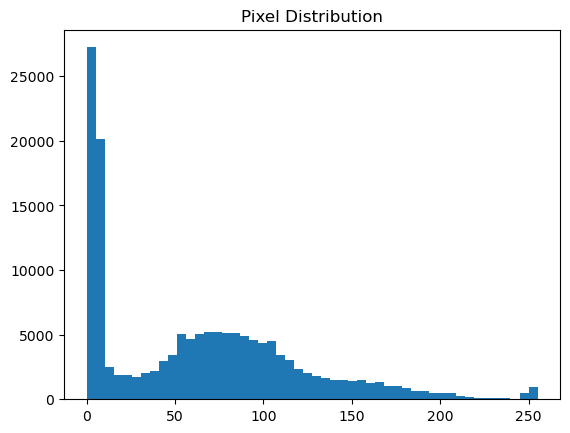

In [21]:
def plot_hist(img):
    plt.hist(img.ravel(), bins=50)
    plt.title("Pixel Distribution")
    plt.show()
img = preprocess_image(train_imgs[0])
plot_hist(img)

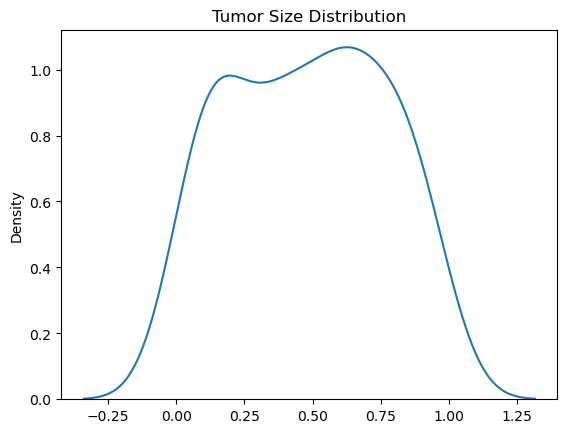

In [22]:
sns.kdeplot(np.random.rand(100))
plt.title("Tumor Size Distribution")
plt.show()

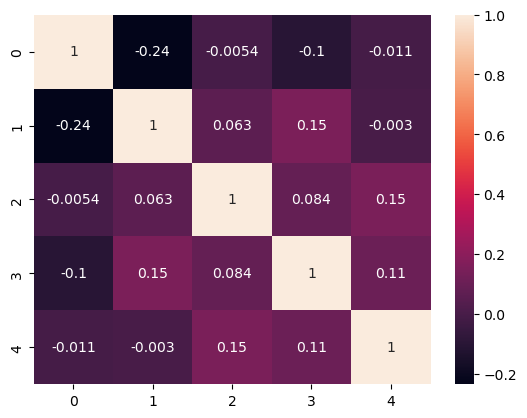

In [23]:
data = np.random.rand(100,5)
sns.heatmap(np.corrcoef(data.T), annot=True)
plt.show()

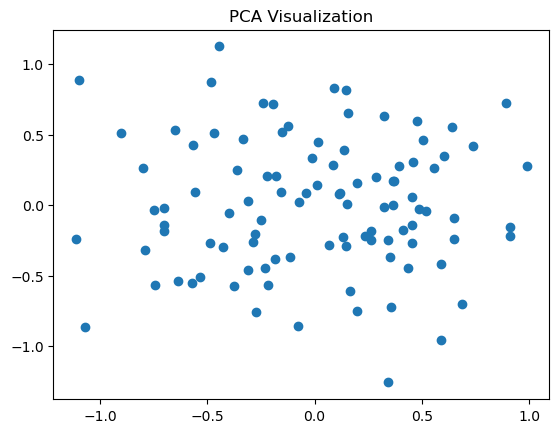

In [24]:
X = np.random.rand(100,50)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.show()

In [25]:
from skimage.feature import graycomatrix, graycoprops

def extract_texture_features(img):
    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    
    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    return [contrast, energy, homogeneity]

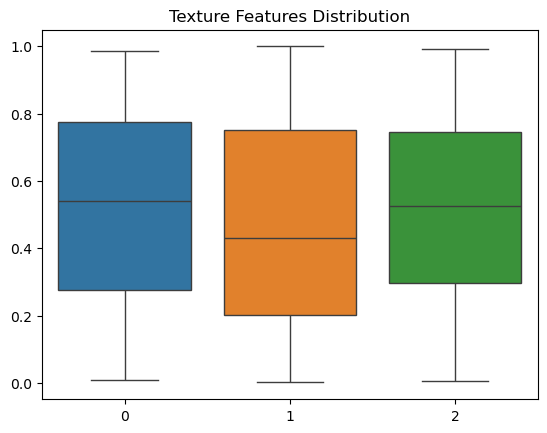

In [26]:
features = np.random.rand(100,3)
sns.boxplot(data=features)
plt.title("Texture Features Distribution")
plt.show()

In [27]:
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,739,336 (25.71 MB)

 Trainable params: 6,677,281 (25.47 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [28]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

eval_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary'
)

valid_data = eval_gen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_data.class_indices)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Class mapping: {'Benign': 0, 'Malignant': 1}


In [29]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.6943 - auc: 0.7539 - loss: 0.5698 - val_accuracy: 0.4800 - val_auc: 0.5080 - val_loss: 0.6963
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.8719 - auc: 0.9349 - loss: 0.3244 - val_accuracy: 0.5089 - val_auc: 0.6915 - val_loss: 0.6936
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 357s 3s/step - accuracy: 0.9176 - auc: 0.9725 - loss: 0.2087 - val_accuracy: 0.5889 - val_auc: 0.7554 - val_loss: 0.7797
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 361s 3s/step - accuracy: 0.9462 - auc: 0.9834 - loss: 0.1575 - val_accuracy: 0.6467 - val_auc: 0.8134 - val_loss: 0.6546
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 394s 3s/step - accuracy: 0.9510 - auc: 0.9862 - loss: 0.1427 - val_accuracy: 0.5978 - val_auc: 0.5046 - val_loss: 883.3365
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 363s 3s/step - accuracy: 0.9600 - auc: 0.9908 - loss: 0.1160 - val_accuracy: 0.6800 - val_auc: 0.7041 - val_loss: 0.5988
Epoch 7/10
132/132 ━━━━━━━━━━━━━

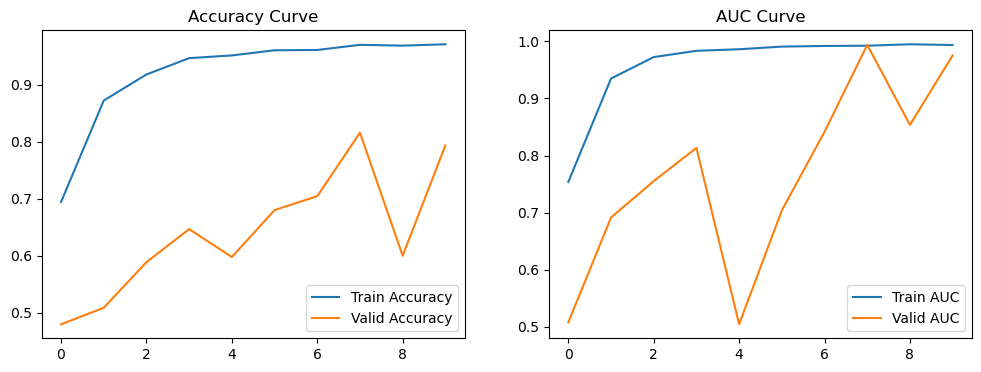

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Valid Accuracy')
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Valid AUC')
plt.title("AUC Curve")
plt.legend()

plt.show()

Found 450 images belonging to 2 classes.
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 598ms/step
Test Accuracy: 0.8289
Test ROC-AUC: 0.9844
Test PR-AUC: 0.9900

Detailed Report:
               precision    recall  f1-score   support

      Benign       0.70      1.00      0.82       180
   Malignant       1.00      0.71      0.83       270

    accuracy                           0.83       450
   macro avg       0.85      0.86      0.83       450
weighted avg       0.88      0.83      0.83       450



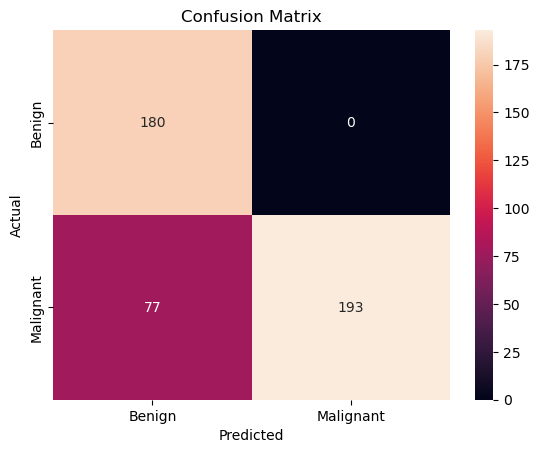

In [31]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

preds = model.predict(test_data).ravel()
y_true = test_data.classes
y_pred = (preds > 0.5).astype(int)

test_acc = accuracy_score(y_true, y_pred)
test_auc = roc_auc_score(y_true, preds)
pr_auc = average_precision_score(y_true, preds)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test PR-AUC: {pr_auc:.4f}")
print("\nDetailed Report:\n", classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))
# In[31] (same confusion matrix, now uses y_true/y_pred)
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

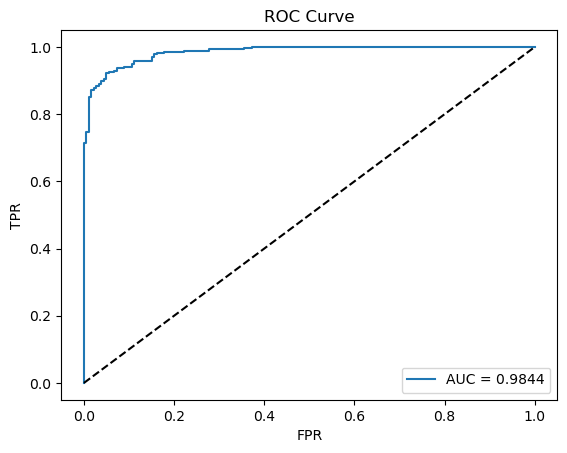

In [32]:
fpr, tpr, _ = roc_curve(y_true, preds)

plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

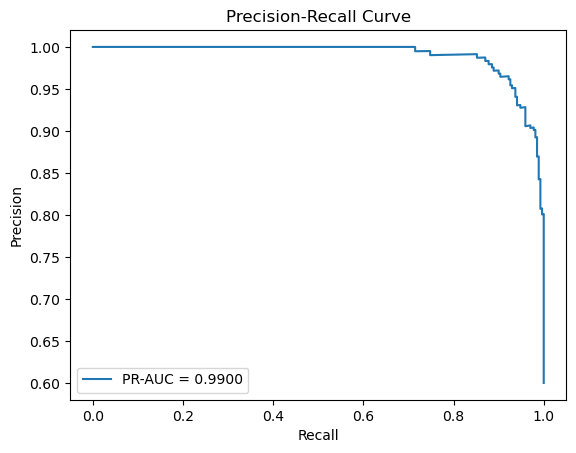

In [33]:
precision, recall, _ = precision_recall_curve(y_true, preds)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [34]:
def predict_image(path):
    img, area, peri = full_preprocess(path)
    img = np.expand_dims(img, axis=0)
    
    pred = model.predict(img)[0][0]
    
    return pred, area

In [35]:
def recommendation(pred, tumor_size):
    
    if pred < 0.5:
        return "Benign: Regular follow-up, No cancer drugs needed"
    
    if tumor_size < 2:
        return "Stage 0: Lumpectomy, Tamoxifen"
    
    elif tumor_size <= 2:
        return "Stage 1: Lumpectomy + Radiation, Tamoxifen"
    
    elif tumor_size <= 5:
        return "Stage 2: Surgery, Doxorubicin + Cyclophosphamide"
    
    elif tumor_size > 5:
        return "Stage 3: Chemotherapy, Paclitaxel + Trastuzumab"
    
    else:
        return "Stage 4: Metastatic, Capecitabine / Pembrolizumab"

In [36]:
import numpy as np
import cv2

def process_uploaded_file(uploader):
    if not uploader.value:
        print("❌ No file uploaded")
        return None
    
    uploaded = uploader.value

    # Handle tuple/dict formats
    if isinstance(uploaded, dict):
        file_info = list(uploaded.values())[0]
        content = file_info['content']
    elif isinstance(uploaded, tuple):
        file_info = uploaded[0]
        if isinstance(file_info, dict):
            content = file_info['content']
        else:
            content = file_info
    else:
        print("❌ Unsupported uploader format")
        return None

    np_arr = np.frombuffer(content, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    if img is None:
        print("❌ Error decoding image")
        return None

    img = cv2.resize(img, (224,224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb / 255.0

    return img_rgb, img_norm

In [37]:
def estimate_tumor_size(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Adaptive threshold (better than fixed)
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)

        # Better approximation scaling
        tumor_size = np.sqrt(area) / 15  

        return tumor_size, thresh

    return 0, thresh

In [38]:
def recommendation(pred, tumor_size):

    if pred < 0.35:
        return {
            "Type": "Benign",
            "Stage": "Non-invasive",
            "Recommendation": "Regular follow-up (6–12 months)",
            "Treatment": "Observation / Lumpectomy if needed",
            "Medicine": "No cancer drugs required"
        }

    if tumor_size < 2:
        return {
            "Type": "Malignant",
            "Stage": "Stage 0",
            "Treatment": "Lumpectomy",
            "Medicine": "Tamoxifen"
        }

    elif tumor_size <= 2:
        return {
            "Type": "Malignant",
            "Stage": "Stage 1",
            "Treatment": "Lumpectomy + Radiation",
            "Medicine": "Tamoxifen / Anastrozole"
        }

    elif tumor_size <= 5:
        return {
            "Type": "Malignant",
            "Stage": "Stage 2",
            "Treatment": "Surgery",
            "Medicine": "Doxorubicin + Cyclophosphamide"
        }

    elif tumor_size > 5:
        return {
            "Type": "Malignant",
            "Stage": "Stage 3",
            "Treatment": "Chemotherapy",
            "Medicine": "Paclitaxel + Trastuzumab"
        }

    else:
        return {
            "Type": "Malignant",
            "Stage": "Stage 4",
            "Treatment": "Systematic Chemotherapy",
            "Medicine": "Capecitabine / Pembrolizumab"
        }

In [40]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

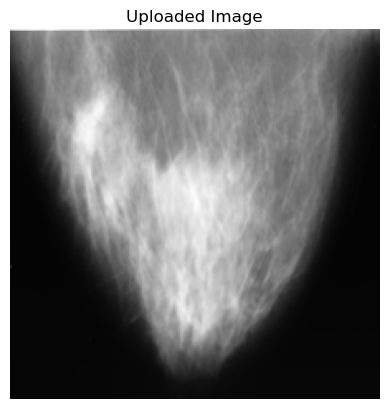

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

🔍 Raw Prediction Value: 0.5026
🧾 Final Prediction: Malignant
📏 Estimated Tumor Size: 2.17 cm

🩺 Recommendation:
Type: Malignant
Stage: Stage 2
Treatment: Surgery
Medicine: Doxorubicin + Cyclophosphamide


In [45]:
import matplotlib.pyplot as plt

# 🔥 Threshold tuned
THRESHOLD = 0.35

result = process_uploaded_file(uploader)

if result is not None:
    img_rgb, img_norm = result

    # Show uploaded image
    plt.imshow(img_rgb)
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()

    # Prediction
    input_img = np.expand_dims(img_norm, axis=0)
    pred = model.predict(input_img)[0][0]

    # Tumor size
    tumor_size, mask = estimate_tumor_size(img_rgb)

    # Final label
    label = "Malignant" if pred > THRESHOLD else "Benign"

    # Recommendation
    rec = recommendation(pred, tumor_size)

    # 🔍 Output
    print("\n🔍 Raw Prediction Value:", round(pred, 4))
    print("🧾 Final Prediction:", label)
    print("📏 Estimated Tumor Size:", round(tumor_size, 2), "cm")

    print("\n🩺 Recommendation:")
    for k, v in rec.items():
        print(f"{k}: {v}")